In [2]:
pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.2/539.2 kB 1.3 MB/s eta 0:00:000m eta -:--:--
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn import metrics

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional, GlobalMaxPooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

2025-11-20 17:13:08.311532: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
# Load the dataset
df = pd.read_csv('./spam.csv', encoding='latin-1')

# Clean the dataset - keep only relevant columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("Dataset Overview:")
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

Dataset Overview:
Dataset shape: (5572, 2)

First 5 rows:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


ValueError: If using all scalar values, you must pass an index

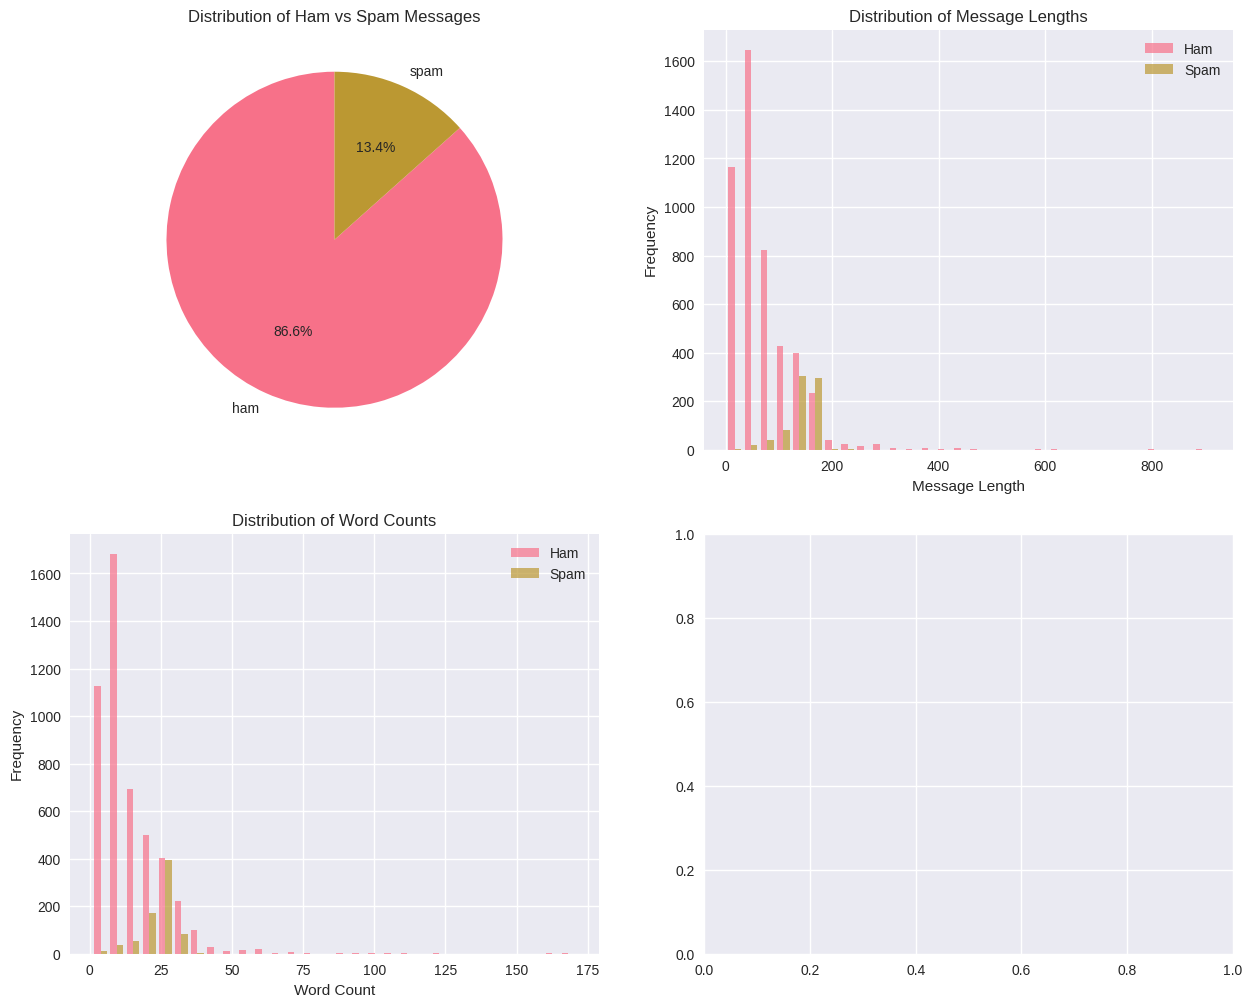

In [5]:
# Create subplots for EDA
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 2.1 Class Distribution
class_dist = df['label'].value_counts()
axes[0,0].pie(class_dist.values, labels=class_dist.index, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Distribution of Ham vs Spam Messages')

# 2.2 Message Length Analysis
df['message_length'] = df['message'].apply(len)
ham_lengths = df[df['label'] == 'ham']['message_length']
spam_lengths = df[df['label'] == 'spam']['message_length']

axes[0,1].hist([ham_lengths, spam_lengths], bins=30, label=['Ham', 'Spam'], alpha=0.7)
axes[0,1].set_xlabel('Message Length')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Distribution of Message Lengths')
axes[0,1].legend()

# 2.3 Word Count Analysis
df['word_count'] = df['message'].apply(lambda x: len(x.split()))
ham_words = df[df['label'] == 'ham']['word_count']
spam_words = df[df['label'] == 'spam']['word_count']

axes[1,0].hist([ham_words, spam_words], bins=30, label=['Ham', 'Spam'], alpha=0.7)
axes[1,0].set_xlabel('Word Count')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Word Counts')
axes[1,0].legend()

# 2.4 Summary Statistics
stats_df = pd.DataFrame({
    'Message Length': df.groupby('label')['message_length'].describe()[['mean', 'std', 'min', 'max']],
    'Word Count': df.groupby('label')['word_count'].describe()[['mean', 'std', 'min', 'max']]
})
axes[1,1].axis('off')
axes[1,1].text(0.1, 0.9, 'Summary Statistics:', fontsize=12, fontweight='bold')
axes[1,1].text(0.1, 0.7, str(stats_df), fontsize=8, family='monospace')
axes[1,1].set_title('Statistical Summary')

plt.tight_layout()
plt.show()

# Print additional statistics
print("\n" + "="*50)
print("DATA ANALYSIS SUMMARY")
print("="*50)
print(f"Total messages: {len(df)}")
print(f"Ham messages: {len(df[df['label']=='ham'])} ({len(df[df['label']=='ham'])/len(df)*100:.2f}%)")
print(f"Spam messages: {len(df[df['label']=='spam'])} ({len(df[df['label']=='spam'])/len(df)*100:.2f}%)")
print(f"Average message length - Ham: {ham_lengths.mean():.2f}, Spam: {spam_lengths.mean():.2f}")
print(f"Average word count - Ham: {ham_words.mean():.2f}, Spam: {spam_words.mean():.2f}")

Generating Word Clouds...


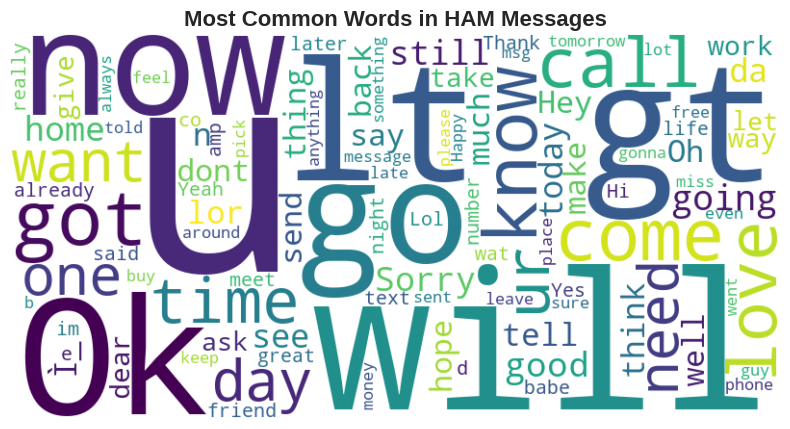

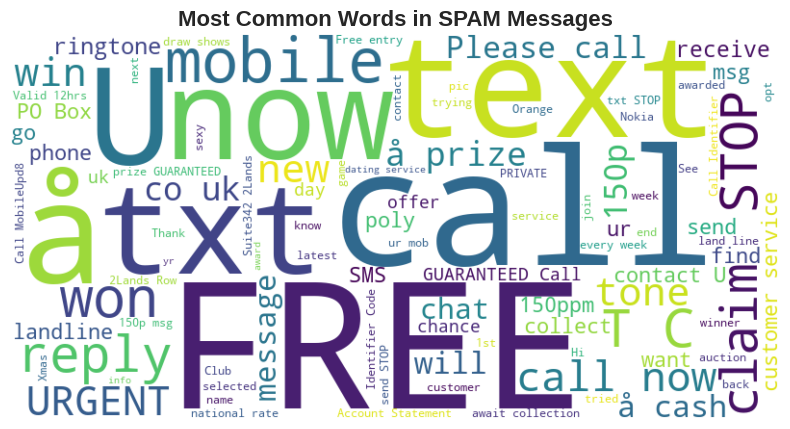

In [6]:
# Generate word clouds for ham and spam messages
def generate_wordcloud(text, title):
    wordcloud = WordCloud(
        width=800, 
        height=400, 
        background_color='white',
        max_words=100,
        colormap='viridis'
    ).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.show()

# Combine all messages for each class
ham_text = ' '.join(df[df['label'] == 'ham']['message'])
spam_text = ' '.join(df[df['label'] == 'spam']['message'])

print("Generating Word Clouds...")
generate_wordcloud(ham_text, 'Most Common Words in HAM Messages')
generate_wordcloud(spam_text, 'Most Common Words in SPAM Messages')

In [7]:
# Prepare data for modeling
print("\n" + "="*50)
print("DATA PREPROCESSING")
print("="*50)

# Convert labels to binary
df['class'] = df['label'].map({'ham': 0, 'spam': 1})
Y = df['class'].values

# Split the data
df_train, df_test, Ytrain, Ytest = train_test_split(
    df['message'], Y, test_size=0.2, random_state=42, stratify=Y
)

print(f"Training set size: {len(df_train)}")
print(f"Testing set size: {len(df_test)}")
print(f"Training set - Ham: {(Ytrain == 0).sum()}, Spam: {(Ytrain == 1).sum()}")
print(f"Testing set - Ham: {(Ytest == 0).sum()}, Spam: {(Ytest == 1).sum()}")

# Tokenization
MAX_VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 160

tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token='<OOV>',
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
)
tokenizer.fit_on_texts(df_train)

# Convert texts to sequences
sequences_train = tokenizer.texts_to_sequences(df_train)
sequences_test = tokenizer.texts_to_sequences(df_test)

# Pad sequences
X_train = pad_sequences(sequences_train, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test = pad_sequences(sequences_test, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"\nVocabulary size: {len(tokenizer.word_index)}")
print(f"Shape of training data: {X_train.shape}")
print(f"Shape of testing data: {X_test.shape}")


DATA PREPROCESSING
Training set size: 4457
Testing set size: 1115
Training set - Ham: 3859, Spam: 598
Testing set - Ham: 966, Spam: 149

Vocabulary size: 7919
Shape of training data: (4457, 160)
Shape of testing data: (1115, 160)


In [8]:
def create_spam_detection_model(vocab_size, sequence_length, embedding_dim=100):
    """
    Create LSTM model for spam detection
    """
    # Input layer
    input_layer = Input(shape=(sequence_length,))
    
    # Embedding layer
    embedding = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=sequence_length,
        mask_zero=True
    )(input_layer)
    
    # LSTM layers
    lstm_layer = LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)(embedding)
    
    # Global max pooling
    pooling_layer = GlobalMaxPooling1D()(lstm_layer)
    
    # Dense layers
    dense_layer = Dense(32, activation='relu')(pooling_layer)
    dense_layer = Dropout(0.3)(dense_layer)
    
    # Output layer
    output_layer = Dense(1, activation='sigmoid')(dense_layer)
    
    # Create model
    model = Model(inputs=input_layer, outputs=output_layer)
    
    return model

# Create the model
print("\n" + "="*50)
print("MODEL ARCHITECTURE")
print("="*50)

model = create_spam_detection_model(
    vocab_size=MAX_VOCAB_SIZE,
    sequence_length=MAX_SEQUENCE_LENGTH,
    embedding_dim=128
)

# Display model summary
model.summary()

# Compile the model
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)


MODEL ARCHITECTURE


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 160, 128)  │  2,560,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 160)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 160, 64)   │     49,408 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ lstm[0][0]        │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,611,521 (9.96 MB)

 Trainable params: 2,611,521 (9.96 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Callbacks for better training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.0001,
    verbose=1
)

print("\n" + "="*50)
print("MODEL TRAINING")
print("="*50)

# Train the model
history = model.fit(
    x=X_train,
    y=Ytrain,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


MODEL TRAINING
Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - accuracy: 0.9989 - loss: 0.0061 - val_accuracy: 0.9865 - val_loss: 0.0626 - learning_rate: 1.0000e-04
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.9986 - loss: 0.0069 - val_accuracy: 0.9877 - val_loss: 0.0561 - learning_rate: 1.0000e-04
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.9997 - loss: 0.0048 - val_accuracy: 0.9854 - val_loss: 0.0639 - learning_rate: 1.0000e-04
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.9997 - loss: 0.0044 - val_accuracy: 0.9877 - val_loss: 0.0610 - learning_rate: 1.0000e-04
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.9994 - loss: 0.0038 - val_accuracy: 0.9865 - val_loss: 0.0657 - learning_rate: 1.0000e-04
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.9865 - val_loss: 0.0728 - learning_rate: 1.0000e-04
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 

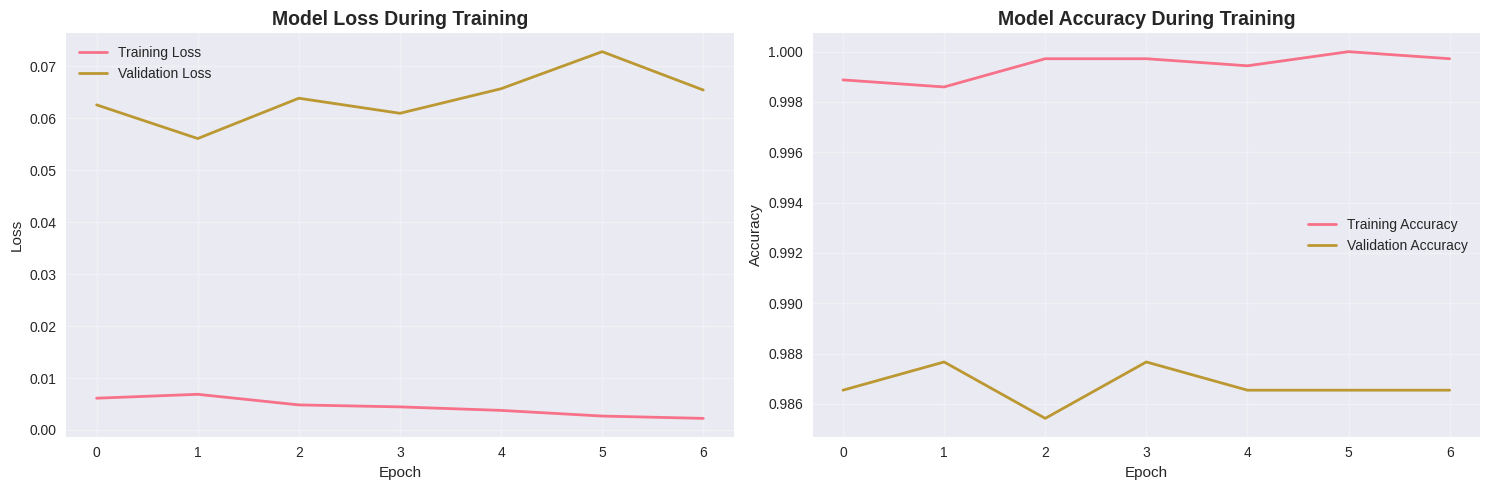

In [12]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss During Training', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy During Training', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)

# Make predictions
Ypred_proba = model.predict(X_test)
Ypred = (Ypred_proba > 0.5).astype("int32").flatten()

# Calculate metrics
accuracy = metrics.accuracy_score(Ytest, Ypred)
precision = metrics.precision_score(Ytest, Ypred)
recall = metrics.recall_score(Ytest, Ypred)
f1 = metrics.f1_score(Ytest, Ypred)
conf_matrix = metrics.confusion_matrix(Ytest, Ypred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Classification report
print("\nClassification Report:")
print(metrics.classification_report(Ytest, Ypred, target_names=['Ham', 'Spam']))


MODEL EVALUATION
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step  
Accuracy:  0.9883
Precision: 0.9789
Recall:    0.9329
F1-Score:  0.9553

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       966
        Spam       0.98      0.93      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



NameError: name 'sn' is not defined

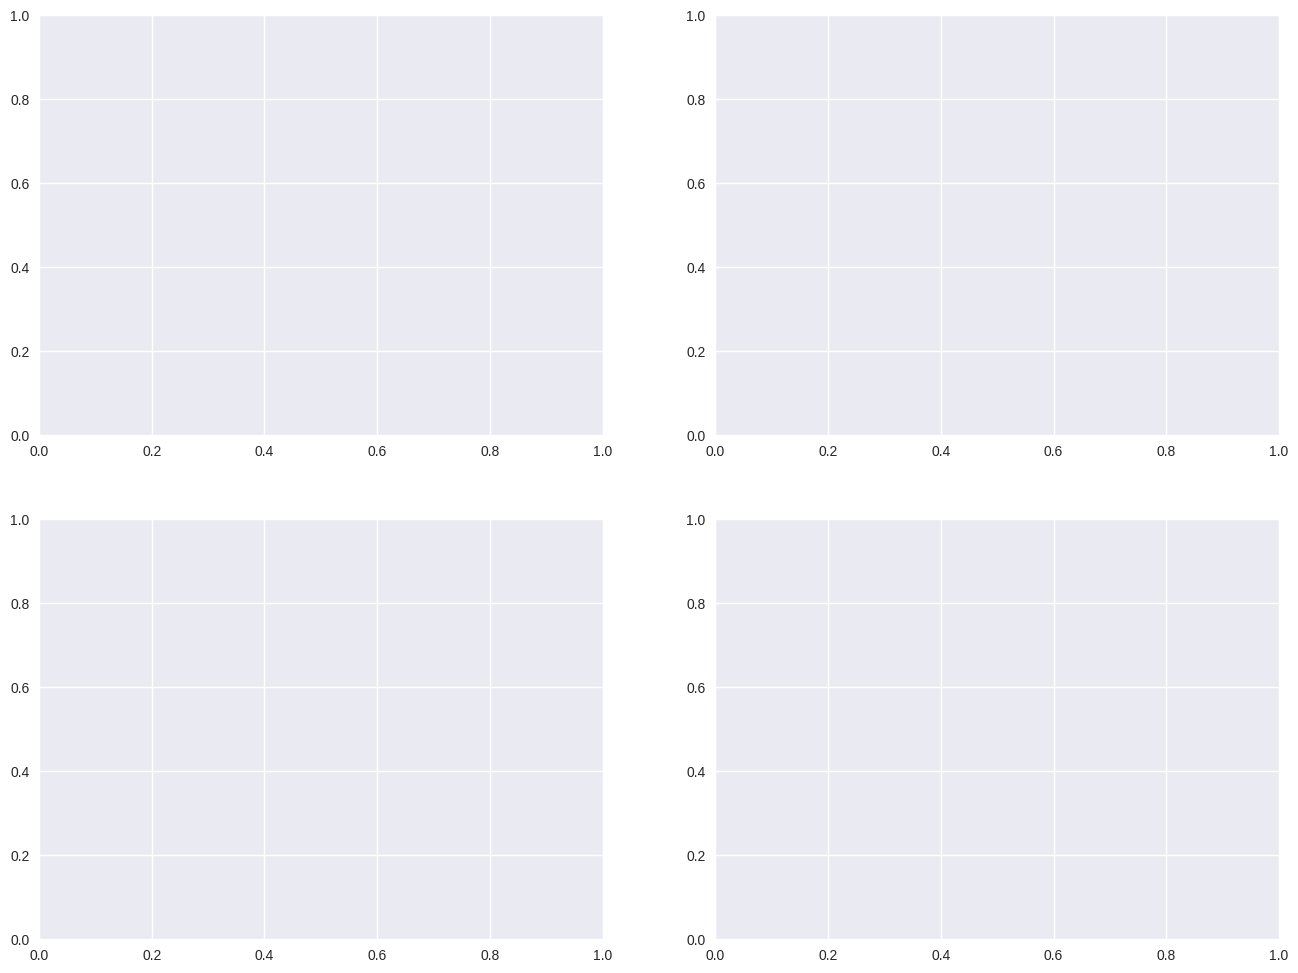

In [14]:
# Create comprehensive evaluation visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 9.1 Confusion Matrix
cm = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]
sn.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', 
           xticklabels=['Predicted Ham', 'Predicted Spam'],
           yticklabels=['True Ham', 'True Spam'], ax=axes[0,0])
axes[0,0].set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')

# 9.2 ROC Curve
fpr, tpr, thresholds = metrics.roc_curve(Ytest, Ypred_proba)
roc_auc = metrics.auc(fpr, tpr)

axes[0,1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0,1].set_xlim([0.0, 1.0])
axes[0,1].set_ylim([0.0, 1.05])
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 9.3 Precision-Recall Curve
precision_curve, recall_curve, _ = metrics.precision_recall_curve(Ytest, Ypred_proba)
axes[1,0].plot(recall_curve, precision_curve, color='green', lw=2)
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# 9.4 Metrics Comparison
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy, precision, recall, f1]
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']

bars = axes[1,1].bar(metrics_names, metrics_values, color=colors, alpha=0.7)
axes[1,1].set_ylim(0, 1)
axes[1,1].set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Score')

# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    axes[1,1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                  f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
# Test the model with custom examples
print("\n" + "="*50)
print("SAMPLE PREDICTIONS")
print("="*50)

# Sample messages for testing
test_messages = [
    "Congratulations! You've won a $1000 Walmart gift card. Text YES to claim your prize!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your bank account has been suspended. Click here to verify: http://bit.ly/secure-bank",
    "Can you pick up some milk on your way home?",
    "FREE entry into our £500 weekly cash prize! Reply WIN to enter. T&C apply."
]

def predict_message(message, model, tokenizer, max_length):
    """Predict if a message is spam or ham"""
    # Preprocess the message
    sequence = tokenizer.texts_to_sequences([message])
    padded_sequence = pad_sequences(sequence, maxlen=max_length, padding='post', truncating='post')
    
    # Make prediction
    prediction = model.predict(padded_sequence, verbose=0)[0][0]
    label = "SPAM" if prediction > 0.5 else "HAM"
    confidence = prediction if prediction > 0.5 else 1 - prediction
    
    return label, confidence, prediction

# Test each message
for i, message in enumerate(test_messages, 1):
    label, confidence, raw_score = predict_message(message, model, tokenizer, MAX_SEQUENCE_LENGTH)
    print(f"\nMessage {i}:")
    print(f"Text: {message}")
    print(f"Prediction: {label} (Confidence: {confidence:.4f}, Raw Score: {raw_score:.4f})")


SAMPLE PREDICTIONS

Message 1:
Text: Congratulations! You've won a $1000 Walmart gift card. Text YES to claim your prize!
Prediction: SPAM (Confidence: 0.9983, Raw Score: 0.9983)

Message 2:
Text: Hey, are we still meeting for lunch tomorrow?
Prediction: HAM (Confidence: 1.0000, Raw Score: 0.0000)

Message 3:
Text: URGENT: Your bank account has been suspended. Click here to verify: http://bit.ly/secure-bank
Prediction: SPAM (Confidence: 0.9815, Raw Score: 0.9815)

Message 4:
Text: Can you pick up some milk on your way home?
Prediction: HAM (Confidence: 1.0000, Raw Score: 0.0000)

Message 5:
Text: FREE entry into our £500 weekly cash prize! Reply WIN to enter. T&C apply.
Prediction: SPAM (Confidence: 0.9994, Raw Score: 0.9994)


In [16]:
# Analyze important words for classification
print("\n" + "="*50)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*50)

# Get most frequent words in spam messages
spam_words = []
for message in df[df['label'] == 'spam']['message']:
    spam_words.extend(message.lower().split())

ham_words = []
for message in df[df['label'] == 'ham']['message']:
    ham_words.extend(message.lower().split())

# Count word frequencies
spam_word_freq = Counter(spam_words)
ham_word_freq = Counter(ham_words)

# Get top 20 spam words
top_spam_words = spam_word_freq.most_common(20)
top_ham_words = ham_word_freq.most_common(20)

print("\nTop 20 words in SPAM messages:")
for word, count in top_spam_words:
    print(f"{word}: {count}")

print("\nTop 20 words in HAM messages:")
for word, count in top_ham_words:
    print(f"{word}: {count}")


FEATURE IMPORTANCE ANALYSIS

Top 20 words in SPAM messages:
to: 682
a: 373
call: 342
your: 263
you: 252
the: 204
for: 201
or: 188
free: 180
2: 169
is: 152
ur: 144
on: 141
txt: 136
have: 135
from: 127
and: 122
u: 117
text: 112
mobile: 109

Top 20 words in HAM messages:
i: 2172
you: 1665
to: 1544
the: 1113
a: 1046
u: 874
and: 845
in: 786
my: 741
is: 710
me: 584
of: 518
for: 496
that: 442
it: 440
have: 433
your: 413
but: 413
are: 405
so: 399
